# **Task 1 — Data Loading & Exploration**


## **Import Libraries**

In [78]:
import pandas as pd
import numpy as np

## **Load Dataset**

Load the housing dataset into a pandas DataFrame.

In [79]:
df = pd.read_csv("Housing.csv")

## Display all rows and columns of the DataFrame.

In [80]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


## **Display First 5 Rows**

View the first five records of the dataset.

In [81]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## **Check How Many Rows and Columns Are There**

Display the total number of rows and columns in the DataFrame.

In [82]:
# (row, column)

df.shape

(545, 13)

## **Display Dataset Information**

Display information about the DataFrame, including column names, data types, and the number of non-null values.

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## **Identify Target Variable and Features**

Separate the dataset into features (X) and the target variable (y), where price is the value to be predicted.

In [84]:
x = df.drop('price', axis=1)
y = df['price']

## **Check for Missing Values in Each Column**

Count and display the number of missing (null) values in each column of the dataset.

In [85]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0




---



# **Task 2 — Data Cleaning**


## **Handle Missing Values / Remove duplicate rows**

**Note:** Based on the dataset, all columns have 545 non-null values, so there are no missing values.

In [86]:
# Remove all rows that contain any missing values.

df.dropna(inplace=True)

## **Convert Categorical Columns into Numeric Form Using One-Hot Encoding**

Convert all categorical columns into numerical values using one-hot encoding and remove one dummy column to avoid multicollinearity.

In [87]:
df = pd.get_dummies(df, drop_first=True)

df.columns  # Display all columns after one-hot encoding.

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [89]:
df

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,True,False,True,False,False,False,False,True
541,1767150,2400,3,1,1,0,False,False,False,False,False,False,True,False
542,1750000,3620,2,1,1,0,True,False,False,False,False,False,False,True
543,1750000,2910,3,1,1,0,False,False,False,False,False,False,False,False


## **Remove Less Useful Columns**

Select only the most relevant features that are likely to influence house prices.

In [90]:
x = df[['area', 'bedrooms', 'bathrooms', 'stories',
        'mainroad_yes', 'guestroom_yes', 'basement_yes',
        'airconditioning_yes', 'parking', 'prefarea_yes']]

**Note:** Since the dataset has only a few features, I keep all encoded feature columns.

Use all available features except price to maximize the information available for prediction.

In [91]:
x = df.drop('price', axis=1)
y = df['price']



---



# **Task 3 — Model Building**


## **Split the Data into Training and Testing Sets (80/20)**

Split the dataset into 80% training data and 20% testing data to train and evaluate the machine learning model.

In [92]:
import sklearn.model_selection as ms

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [93]:
# Display the number of rows and columns in the training and testing datasets.

print("Training Features:", x_train.shape)
print("Testing Features:", x_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (436, 13)
Testing Features: (109, 13)
Training Target: (436,)
Testing Target: (109,)


## **Train a Linear Regression Model**

Create a Linear Regression model and train it using the training data to learn the relationship between house features and price.

In [94]:
import sklearn.linear_model as lm

model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

## **Evaluate the Model Using MAE, RMSE, and R² Score**

In [95]:
# Use the trained Linear Regression model to predict house prices for the test dataset.

y_pred = model.predict(x_test)

In [96]:
# Import the metrics needed to evaluate the performance of the model.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [97]:
# Calculate and display the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score of the model.

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184


## **Train a Random Forest Regressor Model**



In [98]:
# Create and train a Random Forest Regressor using 100 decision trees to predict house prices.

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [99]:
# Use the trained Random Forest model to predict house prices for the test data.

rf_pred = rf_model.predict(X=x_test)

In [100]:
# Calculate and display MAE, RMSE, and R² Score for the Random Forest model.

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R² Score:", rf_r2)

Random Forest MAE: 1021546.0353211008
Random Forest RMSE: 1400565.9728553821
Random Forest R² Score: 0.611918531405699


In [101]:
# Compare the performance metrics of both models to determine which predicts house prices more accurately.

print("Linear Regression")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

print("\nRandom Forest Regressor")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Linear Regression
MAE: 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184

Random Forest Regressor
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [102]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R² Score': [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919




---



# **Task 4 — Visualization**

## **Chart 1: Histogram of House Prices**

In [103]:
import matplotlib.pyplot as plt

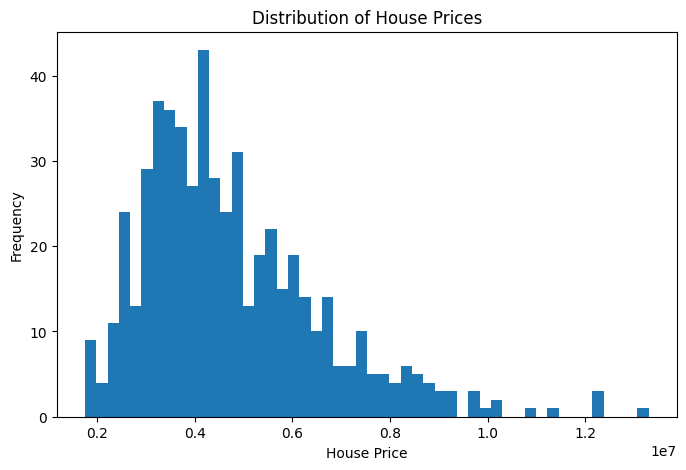

In [104]:
# Create a histogram to visualize how house prices are distributed across the dataset.

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=50)
plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Frequency')
plt.show()

## **Chart 2: Correlation Heatmap**

In [105]:
import seaborn as sns

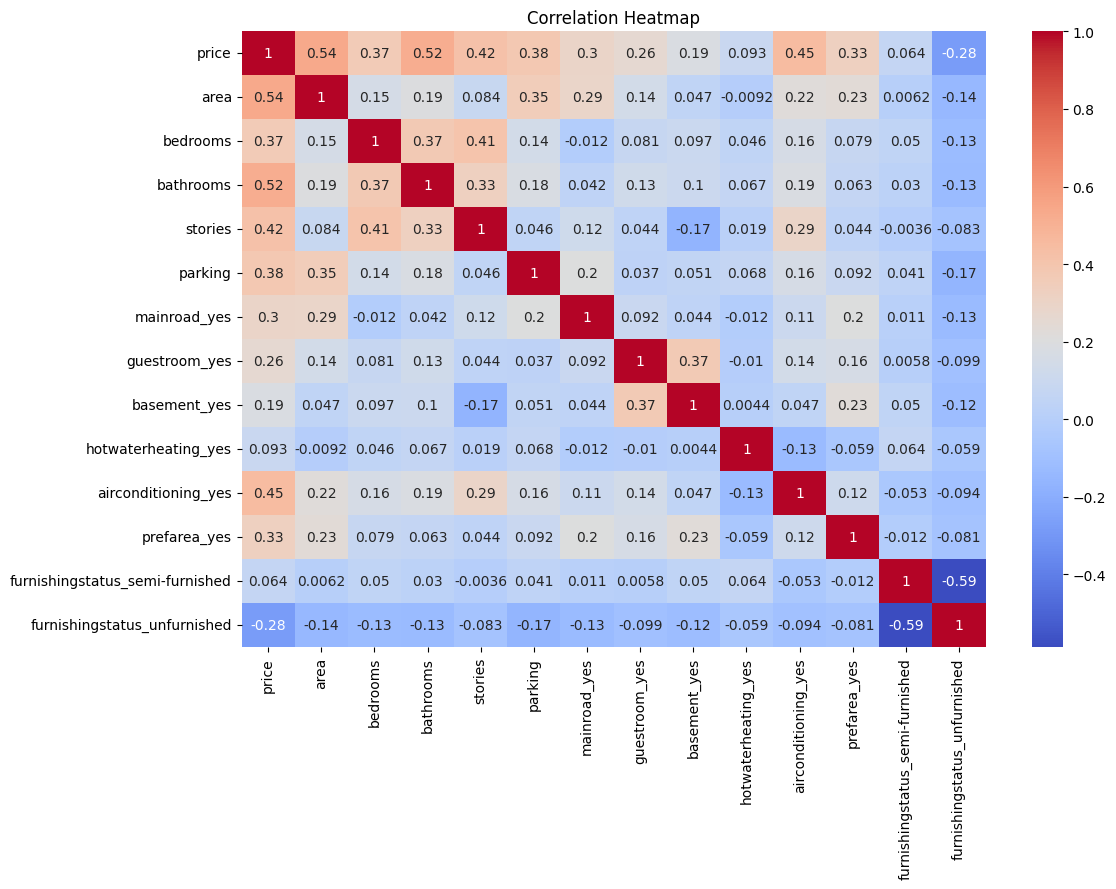

In [106]:
#Display correlations between features to identify which variables have the strongest relationship with house price.

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## **Chart 3: Actual vs Predicted House Prices**

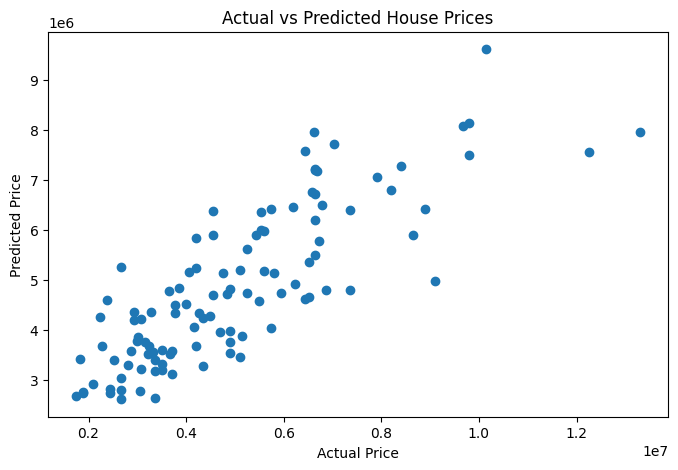

In [107]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()



---



# **Task 5 — Insights & Summary**


## 1. Which Features Influence House Price the Most?

Based on the correlation analysis and model results, the most influential features for house price prediction are:

* Area – Larger houses generally have higher prices.
* Bathrooms – Houses with more bathrooms tend to be more expensive.
* Air Conditioning – Houses with air conditioning often have higher prices.
* Stories – Multi-story houses are usually priced higher.
* Parking – More parking spaces positively affect house prices.


## 2. How Accurate Was Your Model?

The model was evaluated using MAE, RMSE, and R² Score.

* A low MAE and RMSE indicate that the model’s predictions are close to the actual house prices.
* The R² Score shows how much of the variation in house prices is explained by the model.

## 3. What Surprised You in the Data?

One surprising finding was that house price was influenced by more than just size. Features like air conditioning, parking, and preferred location had a noticeable impact on property value.

I also observed that some houses with similar areas had very different prices, showing that amenities and location play a major role in determining house prices.

## 4. One Recommendation for a Real Estate Business

Real estate businesses should focus on properties with features that significantly increase value, such as larger living areas, multiple bathrooms, parking facilities, and air conditioning.

**Recommendation:**
Invest in improving property amenities and highlight these features in marketing campaigns, as they have a strong influence on house prices and buyer preferences.